# CBERS4A

[![Repo](https://img.shields.io/badge/GitHub-repo-blue?logo=github&logoColor=f5f5f5)](https://github.com/gabriel-russo/cbers4asat)


In [1]:
import os
import pprint
import tempfile
from datetime import date, datetime
from pathlib import Path

import geopandas as gpd
import rasterio
import rasterio.plot
from cbers4asat import Cbers4aAPI
from cbers4asat import Collections as coll
from cbers4asat import tools
from dotenv import load_dotenv
from osgeo_utils import gdal_pansharpen

import open_geodata as geo

<br>

---

## Credenciais


In [2]:
load_dotenv()

INPE_MAIL = os.getenv('INPE_MAIL')

<br>

---

## Definição de Área de Interesse

Obtem uma área para que façamos o _download_.


In [3]:
# Crio pasta temporária
temp_path = Path(tempfile.gettempdir()) / 'open_geodata' / 'sfb'
temp_path.mkdir(exist_ok=True)

In [4]:
# Instancia classe IBGE
sfb = geo.br.sicar.SICAR(
    tesseract_path='C:\\Program Files\\Tesseract-OCR\\tesseract.exe'
)

# Download Data
# sfb.download_data(
#     sigla_estado=geo.br.sicar.State.MA,
#     layer=geo.br.sicar.Polygon.AREA_PROPERTY,
#     output_path=temp_path,
# )

# Lista arquivos baixados
list_files = list(temp_path.glob('*'))
print(list_files)

# Lê o shapefile diretamente do zip
gdf = gpd.read_file(filename=list_files[0])
gdf_bk = gdf

[WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/sfb/AC_AREA_IMOVEL.zip'), WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/sfb/MA_AREA_IMOVEL.zip')]


In [5]:
# Faz o Backup
gdf = gdf_bk

# Filtra propriedades com área definida em um intervalo de áreas (em hectares)
gdf = gdf[(gdf['num_area'] >= 30) & (gdf['num_area'] <= 41)]

# Sorteia uma propriedade
# gdf = gdf.sample(n=1)
gdf = gdf[4:5]

# Crio pasta temporária
temp_path = Path(tempfile.gettempdir()) / 'open_geodata' / 'raster' / 'cbers'
temp_path.mkdir(exist_ok=True)

# Salva
gdf.to_file(
    filename=temp_path / 'limite.gpkg',
    driver='GPKG',
    encoding='utf-8',
    OVERWRITE=True,
)

# Exibe informações do GeoDataFrame filtrado
gdf.info()
gdf.head(2)

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1 entries, 28 to 28
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cod_tema    1 non-null      object  
 1   nom_tema    1 non-null      object  
 2   cod_imovel  1 non-null      object  
 3   mod_fiscal  1 non-null      float64 
 4   num_area    1 non-null      float64 
 5   ind_status  1 non-null      object  
 6   ind_tipo    1 non-null      object  
 7   des_condic  1 non-null      object  
 8   municipio   1 non-null      object  
 9   cod_estado  1 non-null      object  
 10  dat_criaca  1 non-null      object  
 11  dat_atuali  1 non-null      object  
 12  geometry    1 non-null      geometry
dtypes: float64(2), geometry(1), object(10)
memory usage: 112.0+ bytes


,cod_tema,nom_tema,cod_imovel,mod_fiscal,num_area,ind_status,ind_tipo,des_condic,municipio,cod_estado,dat_criaca,dat_atuali,geometry
28,AREA_IMOVEL,Area do Imovel,AC-1200013-4DA9D6F741224F9DBE2CCD6E3472CDA3,0.3396,33.9636,AT,IRU,Aguardando analise,Acrelandia,AC,03/06/2014,07/07/2025,"POLYGON ((-67.11295 -9.76117, -67.11261 -9.761..."


In [6]:
gdf.explore(column='des_condic', tiles='Esri.WorldImagery')

<br>

---

## Bounding Box


In [7]:
# Métricas Web Mercator
gdf = gdf.to_crs(epsg=3857)

# Buffer de 100m
gdf['geometry'] = gdf['geometry'].buffer(distance=100)

# Extract bounding box in WGS84
w, s, e, n = gdf.to_crs(epsg=4326).total_bounds

# Extract bounding box in Web Mercator
# w, s, e, n = gdf.to_crs(epsg=3857).total_bounds
print(w, s, e, n)

-67.12817613839668 -9.76801567024909 -67.11171537386515 -9.759377914336705


<br>

---

## _Download_ Images: CBERS4

- [https://contextily.readthedocs.io/en/latest/](https://contextily.readthedocs.io/en/latest/)


In [8]:
# Inicializando a biblioteca
# E-mail usado no login da plataforma https://www.dgi.inpe.br/catalogo/explore
api = Cbers4aAPI(email=INPE_MAIL)

<br>

No [pdf](http://www.obt.inpe.br/OBT/assuntos/catalogo-cbers-amz-1/niveis-de-processamento-cb4a-cb4-e-amz-1.pdf) há mais informação sobre o nível de processamento.

- **Nível 0 (L0)**: Imagem bruta, sem correção radiométrica nem geométrica.
- **Nível 1 (L1)**: Imagem com correção radiométrica.
- **Nível 2 (L2)**: Imagem com correção radiométrica e correção geométrica de sistema (uso dos dados de efemérides e de atitude do satélite).
- **Nível 2B (L2B)**: Imagem resultante do processamento por passagem. Os pontos de controle existentes em algumas cenas da passagem são usados para refinar os dados de efemérides e/ou atitude. Com esses dados refinados, imagens no nível 2 (L2) são geradas para todas as cenas da passagem. Dessa forma, é possível obter produtos de qualidade geométrica razoável mesmo em cenas com grande cobertura de nuvens ou com distribuição deficiente de pontos de controle, o que inviabilizaria a produção do nível 4 (L4).
- **Nível 3 (L3)**: Imagem com correção radiométrica e correção geométrica de sistema refinada pelo uso de pontos de controle.
- **Nível 4 (L4)**: Imagem ortorretificada, ou seja, imagem com correção radiométrica e correção geométrica de sistema refinada pelo uso de pontos de controle e de um modelo digital de elevação do terreno


In [9]:
# Buscando metadados. Este exemplo utiliza o path row (órbita/ponto).
# Consulte a órbita/ponto: http://www.obt.inpe.br/OBT/assuntos/catalogo-cbers-amz-1
produtos = api.query(
    # Área de interesse. Pode ser: bouding box, path row ou polygon.
    # location=(229, 124),
    location=[e, s, w, n],
    initial_date=date(2024, 1, 1),
    end_date=date(2025, 12, 1),
    cloud=100,
    limit=10,
    collections=[coll.CBERS4A_WPM_L4_DN, coll.CBERS4A_WPM_L2_DN],
)

# Exibindo os resultados
n_scenes = len(produtos['features'])
print(f'Existem {n_scenes} cenas')

Existem 19 cenas


In [10]:
# Ordena pela data
ordered_features = sorted(
    produtos['features'],
    key=lambda scene: datetime.fromisoformat(scene['properties']['datetime']),
    reverse=True,
)

# Imprime cada dicionário ordenado
for scene in ordered_features:
    # print(scene)

    collection = scene['collection']
    cloud_cover = scene['properties']['cloud_cover']

    dt = datetime.fromisoformat(scene['properties']['datetime'])
    print(f'Imagem "{collection}" de {dt} tem {cloud_cover} de cobertura de nuvem')

Imagem "CBERS4A_WPM_L4_DN" de 2025-07-06 14:45:26 tem 10.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L2_DN" de 2025-06-05 14:46:55 tem 40.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L2_DN" de 2025-05-05 14:48:28 tem 20.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L2_DN" de 2025-04-04 14:50:03 tem 90.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L2_DN" de 2025-03-04 14:51:19 tem 90.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L2_DN" de 2025-02-01 14:52:37 tem 70.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L2_DN" de 2025-01-06 14:51:48 tem 70.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L2_DN" de 2024-12-06 14:53:25 tem 70.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L4_DN" de 2024-10-31 14:57:15 tem 30.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L4_DN" de 2024-10-05 14:55:08 tem 60.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L2_DN" de 2024-09-30 14:58:25 tem 90.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L4_DN" de 2024-09-04 14:56:33 tem 10.0 de cobertura de nuvem
Imagem "CBERS4A_WPM_L4_DN" d

In [11]:
#dt_select = datetime.fromisoformat('2024-06-30T13:42:12')
dt_select = datetime.fromisoformat('2025-05-05 14:48:28')

# Seleciona o item
item = next(
    (scene for scene in produtos['features']
     if datetime.fromisoformat(scene['properties']['datetime']) == dt_select),
    None
)

# Recria objeto produtos
produtos = {'type': 'FeatureCollection', 'features': [item]}

<br>

Para fins de testes, quero me manter com apenas uma cena.

In [12]:
# while n_scenes > 1:
#     # Remove uma Cena
#     produtos['features'].pop(0)

#     # Recalcula
#     n_scenes = len(produtos['features'])
#     print(f'Existem {n_scenes} cenas')

# # Resultado
# pprint.pprint(produtos)

<br>

---

## _Geodataframe_ das Miniaturas


In [13]:
# ssss
gdf_thumbnail = api.to_geodataframe(products=produtos)
gdf_thumbnail = gdf_thumbnail.rename_axis(mapper=None)

# Results
gdf_thumbnail.info()
gdf_thumbnail.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1 entries, CBERS4A_WPM23312520250505ETC2 to CBERS4A_WPM23312520250505ETC2
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   geometry     1 non-null      geometry
 1   datetime     1 non-null      object  
 2   path         1 non-null      int64   
 3   row          1 non-null      int64   
 4   satellite    1 non-null      object  
 5   sensor       1 non-null      object  
 6   cloud_cover  1 non-null      float64 
 7   id           1 non-null      object  
 8   bbox         1 non-null      object  
 9   collection   1 non-null      object  
 10  thumbnail    1 non-null      object  
dtypes: float64(1), geometry(1), int64(2), object(7)
memory usage: 96.0+ bytes


,geometry,datetime,path,row,satellite,sensor,cloud_cover,id,bbox,collection,thumbnail
CBERS4A_WPM23312520250505ETC2,"POLYGON ((-67.8758 -9.02277, -67.8723 -10.0732...",2025-05-05T14:48:28,233,125,CBERS4A,WPM,20.0,CBERS4A_WPM23312520250505ETC2,"[-67.8758, -10.0732, -66.8408, -9.01819]",CBERS4A_WPM_L2_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...


In [14]:
gdf_thumbnail.explore(column='id', tiles='Esri.WorldImagery')

<br>

---

## _Download_ Images


In [15]:
# # Bandas escolhidas: vermelha, verde e azul
# # Output do download é opcional e caso omitido será usado o diretório atual
# api.download(
#     products=produtos,
#     bands=['red', 'green', 'blue', 'nir', 'pan'],
#     # Número de downloads simultâneos
#     threads=3,
#     # Pasta que será feito o download
#     outdir=str(temp_path),
#     # Agrupar bandas de uma cena(s) em subpasta(s) no diretório ./downloads
#     with_folder=True,
# )

<br>

---

## Tools


In [16]:
temp_path

WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/raster/cbers')

Lista os diretórios da pasta temporária.


In [17]:
list_dirs = [x for x in list(temp_path.glob('*')) if x.is_dir()]
list_dirs

[WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/raster/cbers/CBERS4A_WPM23312520250505ETC2'),
 WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/raster/cbers/CBERS4A_WPM23312520250706ETC2')]

Escolhe qual a cena que será usada.


In [31]:
scene_path = list_dirs[0]
scene_path

WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/raster/cbers/CBERS4A_WPM23312520250505ETC2')

In [32]:
list_files = list(scene_path.rglob('*.tif'))
list_files

[WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/raster/cbers/CBERS4A_WPM23312520250505ETC2/CBERS_4A_WPM_20250505_233_125_L2_BAND0.tif'),
 WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/raster/cbers/CBERS4A_WPM23312520250505ETC2/CBERS_4A_WPM_20250505_233_125_L2_BAND1.tif'),
 WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/raster/cbers/CBERS4A_WPM23312520250505ETC2/CBERS_4A_WPM_20250505_233_125_L2_BAND2.tif'),
 WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/raster/cbers/CBERS4A_WPM23312520250505ETC2/CBERS_4A_WPM_20250505_233_125_L2_BAND3.tif'),
 WindowsPath('C:/Users/michel/AppData/Local/Temp/open_geodata/raster/cbers/CBERS4A_WPM23312520250505ETC2/CBERS_4A_WPM_20250505_233_125_L2_BAND4.tif')]

<br>

---

### RGB Composite


In [33]:
# Criando a composição cor verdadeira
tools.rgbn_composite(
    red=str(list(scene_path.rglob('*BAND3.tif'))[0]),  # Band 3
    green=str(list(scene_path.rglob('*BAND2.tif'))[0]),  # Band 2
    blue=str(list(scene_path.rglob('*BAND1.tif'))[0]),  # Band 1
    nir=str(list(scene_path.rglob('*BAND4.tif'))[0]),  # Band 4
    outdir=str(scene_path),
    filename='rgbn_composite.tif',
)

<br>

Quero obter o _datum_ do _raster_.


In [35]:
with rasterio.open(fp=str(scene_path / 'rgbn_composite.tif')) as src:
    # Obtem o datum do raster
    raster_datum = src.crs
    print(raster_datum)

    # Para uma descrição mais detalhada:
    # print(src.crs.to_wkt())

EPSG:32719


<br>

Aplico um buffer de 100m ao redor da área de interesse.


In [36]:
# Métricas Web Mercator
gdf = gdf.to_crs(epsg=3857)

# Buffer
gdf['geometry'] = gdf['geometry'].buffer(distance=1000)

# Reset Index
gdf = gdf.reset_index(drop=True)

# ddd
gdf = gdf.to_crs(epsg=4326)

# Results
gdf.info()
gdf.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cod_tema    1 non-null      object  
 1   nom_tema    1 non-null      object  
 2   cod_imovel  1 non-null      object  
 3   mod_fiscal  1 non-null      float64 
 4   num_area    1 non-null      float64 
 5   ind_status  1 non-null      object  
 6   ind_tipo    1 non-null      object  
 7   des_condic  1 non-null      object  
 8   municipio   1 non-null      object  
 9   cod_estado  1 non-null      object  
 10  dat_criaca  1 non-null      object  
 11  dat_atuali  1 non-null      object  
 12  geometry    1 non-null      geometry
dtypes: float64(2), geometry(1), object(10)
memory usage: 236.0+ bytes


,cod_tema,nom_tema,cod_imovel,mod_fiscal,num_area,ind_status,ind_tipo,des_condic,municipio,cod_estado,dat_criaca,dat_atuali,geometry
0,AREA_IMOVEL,Area do Imovel,AC-1200013-4DA9D6F741224F9DBE2CCD6E3472CDA3,0.3396,33.9636,AT,IRU,Aguardando analise,Acrelandia,AC,03/06/2014,07/07/2025,"POLYGON ((-67.14608 -9.77697, -67.14622 -9.750..."


<br>

Converto o _datum_ da área de interesse para o _datum_ do _raster_.


In [37]:
# Métricas Web Mercator
gdf = gdf.to_crs(raster_datum)
gdf['geometry'] = gdf['geometry'].envelope

# Results
gdf.info()
gdf.crs

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cod_tema    1 non-null      object  
 1   nom_tema    1 non-null      object  
 2   cod_imovel  1 non-null      object  
 3   mod_fiscal  1 non-null      float64 
 4   num_area    1 non-null      float64 
 5   ind_status  1 non-null      object  
 6   ind_tipo    1 non-null      object  
 7   des_condic  1 non-null      object  
 8   municipio   1 non-null      object  
 9   cod_estado  1 non-null      object  
 10  dat_criaca  1 non-null      object  
 11  dat_atuali  1 non-null      object  
 12  geometry    1 non-null      geometry
dtypes: float64(2), geometry(1), object(10)
memory usage: 236.0+ bytes


<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [38]:
gdf.explore(column='cod_imovel', tiles='Esri.WorldImagery')

<br>

Obtemnho a geometria do polígono.


<class 'shapely.geometry.polygon.Polygon'>


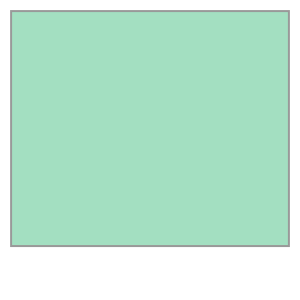

In [39]:
gdf_aoi = gdf.geometry[0]
print(type(gdf_aoi))
gdf_aoi

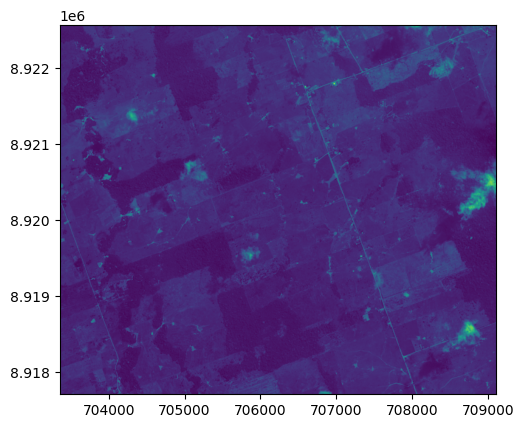

<Axes: >

In [40]:
# Clip
tools.clip(
    raster=str(scene_path / 'rgbn_composite.tif'),
    mask=gdf_aoi,
    outdir=str(scene_path),
    filename='rgbn_composite_clip.tif',
)

# Plotando a imagem
raster = rasterio.open(scene_path / 'rgbn_composite_clip.tif')
rasterio.plot.show(raster)

<br>

---

### _Pansharpening_

_Pansharpening_ é uma técnica de processamento de imagens que combina informações de duas ou mais fontes de imagens de satélite ou aéreas para criar uma única imagem de alta resolução, tanto espacial quanto espectralmente.
Como funciona?

- Imagem Pancromática (PAN) – Possui alta resolução espacial (detalhes nítidos), mas geralmente é em preto e branco (um único canal espectral).
- Imagem Multiespectral (MS) – Contém várias bandas de cores (ex.: vermelho, verde, azul, infravermelho), mas com resolução espacial mais baixa.

O _pansharpening_ funde essas duas imagens, mantendo a riqueza de cores da imagem multiespectral e a nitidez da imagem pancromática.


Observei que quando faz pansharping, não pode ussar NIR....


In [41]:
tools.clip(
    raster=str(list(scene_path.rglob('*BAND0.tif'))[0]),
    mask=gdf_aoi,
    outdir=str(scene_path),
    filename='pan_clip.tif',
)

In [42]:
try:
    tools.pansharpening(
        panchromatic=str(scene_path / 'pan_clip.tif'),  # Band 0,
        multispectral=str(scene_path / 'rgbn_composite_clip.tif'),
        outdir=str(scene_path),
        filename='pansharp.tif',
    )

    # Plotando a imagem
    raster = rasterio.open(scene_path / 'pansharp.tif')
    rasterio.plot.show(raster)    

except:
    print('Provavel erro pois não pode ter NIR (4 bandas)')

Provavel erro pois não pode ter NIR (4 bandas)


<br>


-------


### _Pansharpening_ com GDAL



In [43]:
gdal_pansharpen.gdal_pansharpen(
    pan_name=str(scene_path / 'pan_clip.tif'),
    spectral_names=[str(scene_path / 'rgbn_composite_clip.tif')],
    band_nums=[1, 2, 3],
    dst_filename=str(scene_path / 'pansharp_gdal.tif'),
    # weights=None,
)

0

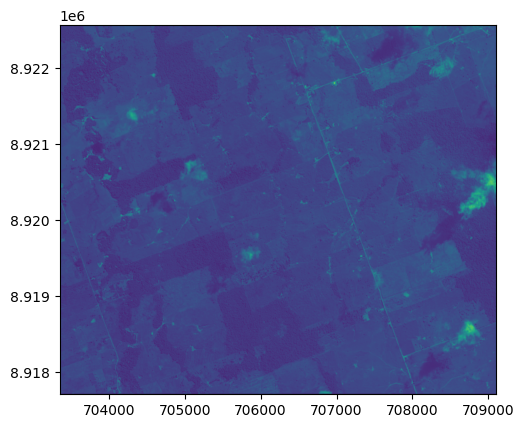

<Axes: >

In [44]:
# Plotando a imagem
raster = rasterio.open(scene_path / 'pansharp_gdal.tif')
rasterio.plot.show(raster)